# 03 · GPU Attestation & Workload Policy Gate

            A policy simulation that keeps hardware trust, workload behavior, and analyst action separate and auditable.

## tl;dr

            Trusted training behavior receives **ALLOW** at **14/100**. Normal behavior on an untrusted GPU receives **BLOCK** at **60/100** because cryptographic trust is a release prerequisite—not a behavior-model prediction.

## Context & Methods

            The demo parser consumes NRAS-shaped synthetic evidence: nonce, signature, measurement, and confidential-computing mode. The production boundary is explicit: real deployments must call NVIDIA attestation services and validate freshness and policy.

            ### Key Assumptions

            - Fixture booleans represent already-verified claims; the lab does not implement cryptography.
            - A failed attestation blocks model-key release even if telemetry looks normal.
            - Behavior evidence can independently block a trusted GPU workload.

## Data

Recreate six scenario reports from deterministic inputs and compare them with the checked-in policy matrix.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook from the repository or a child directory")
sys.path.insert(0, str(ROOT / "src"))

NVIDIA = "#76B900"
ORANGE = "#f97316"
BLUE = "#2563eb"
GOLD = "#d9a404"
PINK = "#db2777"
INK = "#172033"
GRID = "#e5e7eb"
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 11,
    "axes.titlepad": 30,
})

In [2]:
from gpu_trust_guardian.pipeline import analyze_events
from gpu_trust_guardian.simulator import SCENARIOS, build_attestation, generate_events

rows = []
for index, scenario in enumerate(SCENARIOS):
    attestation = build_attestation(scenario != "untrusted_gpu")
    report = analyze_events(generate_events(scenario, 260, 210 + index), attestation, scenario)
    rows.append({
        "scenario": scenario,
        "decision": report.decision,
        "risk_score": report.risk_score,
        "findings": len(report.findings),
        "suspicious_events": report.suspicious_events,
        "attack_paths": len(report.attack_paths),
        "attestation_trusted": report.attestation.trusted,
    })
policy = pd.DataFrame(rows)
policy

,scenario,decision,risk_score,findings,suspicious_events,attack_paths,attestation_trusted
0,trusted_training,ALLOW,14,1,8,8,True
1,benign_inference,ALLOW,14,1,9,9,True
2,cryptomining,QUARANTINE,42,2,55,18,True
3,model_exfiltration,BLOCK,56,2,55,18,True
4,container_escape,BLOCK,76,3,55,18,True
5,untrusted_gpu,BLOCK,60,2,16,11,False


In [3]:
checked_in = pd.DataFrame(json.loads((ROOT / "reports" / "policy-matrix.json").read_text()))
pd.testing.assert_frame_equal(
    policy.sort_values("scenario").reset_index(drop=True),
    checked_in.sort_values("scenario").reset_index(drop=True),
)
assert set(policy["decision"]) == {"ALLOW", "QUARANTINE", "BLOCK"}
print("Recomputed policy matrix matches the checked-in report.")

Recomputed policy matrix matches the checked-in report.


## Results

First compare scenario risk, then isolate the effect of attestation trust.

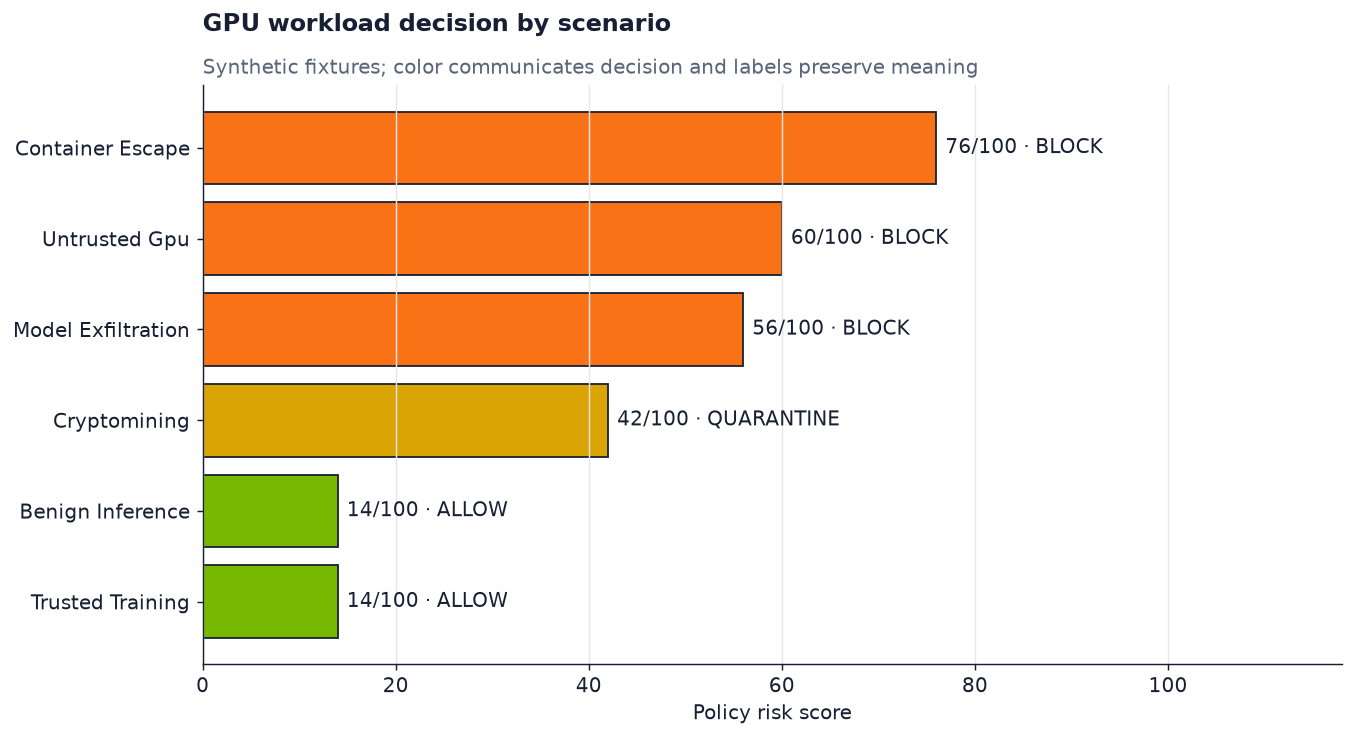

In [4]:
decision_colors = {"ALLOW": NVIDIA, "QUARANTINE": GOLD, "BLOCK": ORANGE}
ordered = policy.sort_values("risk_score")
fig, ax = plt.subplots(figsize=(10.5, 5.8))
bars = ax.barh(
    ordered["scenario"].str.replace("_", " ").str.title(),
    ordered["risk_score"],
    color=[decision_colors[value] for value in ordered["decision"]],
    edgecolor=INK,
)
ax.bar_label(bars, labels=[f"{score}/100 · {decision}" for score, decision in zip(ordered["risk_score"], ordered["decision"])], padding=5)
ax.set_xlim(0, 118)
ax.set_xlabel("Policy risk score")
ax.set_title("GPU workload decision by scenario", loc="left", fontweight="bold")
ax.text(0, 1.02, "Synthetic fixtures; color communicates decision and labels preserve meaning", transform=ax.transAxes, color="#596579")
ax.grid(axis="x", color=GRID, linewidth=.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

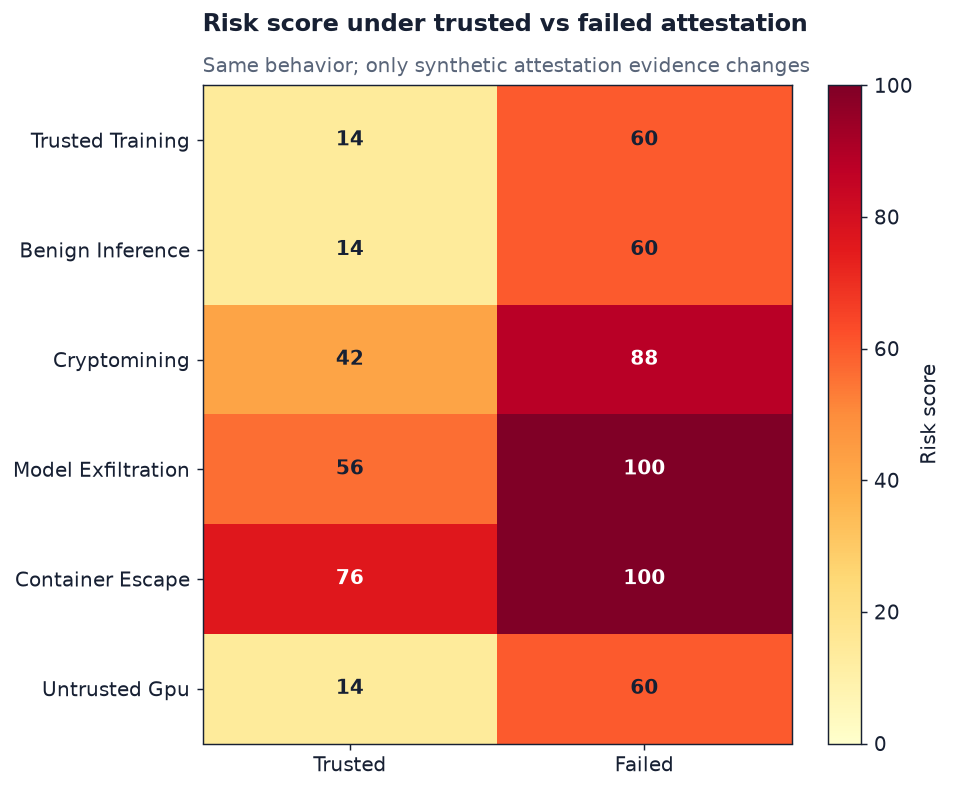

In [5]:
matrix_rows = []
for index, scenario in enumerate(SCENARIOS):
    events = generate_events(scenario, 260, 210 + index)
    for trusted in [True, False]:
        report = analyze_events(events, build_attestation(trusted), scenario)
        matrix_rows.append({"scenario": scenario, "attestation": "Trusted" if trusted else "Failed", "risk_score": report.risk_score, "decision": report.decision})
trust_matrix = pd.DataFrame(matrix_rows)
pivot = trust_matrix.pivot(index="scenario", columns="attestation", values="risk_score").loc[list(SCENARIOS), ["Trusted", "Failed"]]

fig, ax = plt.subplots(figsize=(7.4, 6.2))
image = ax.imshow(pivot.values, cmap="YlOrRd", vmin=0, vmax=100, aspect="auto")
for row in range(pivot.shape[0]):
    for column in range(pivot.shape[1]):
        value = int(pivot.iloc[row, column])
        ax.text(column, row, value, ha="center", va="center", fontweight="bold", color="white" if value >= 70 else INK)
ax.set_xticks(range(2), pivot.columns)
ax.set_yticks(range(len(pivot)), [value.replace("_", " ").title() for value in pivot.index])
ax.set_title("Risk score under trusted vs failed attestation", loc="left", fontweight="bold")
ax.text(0, 1.02, "Same behavior; only synthetic attestation evidence changes", transform=ax.transAxes, color="#596579")
fig.colorbar(image, ax=ax, label="Risk score")
plt.tight_layout()
plt.show()

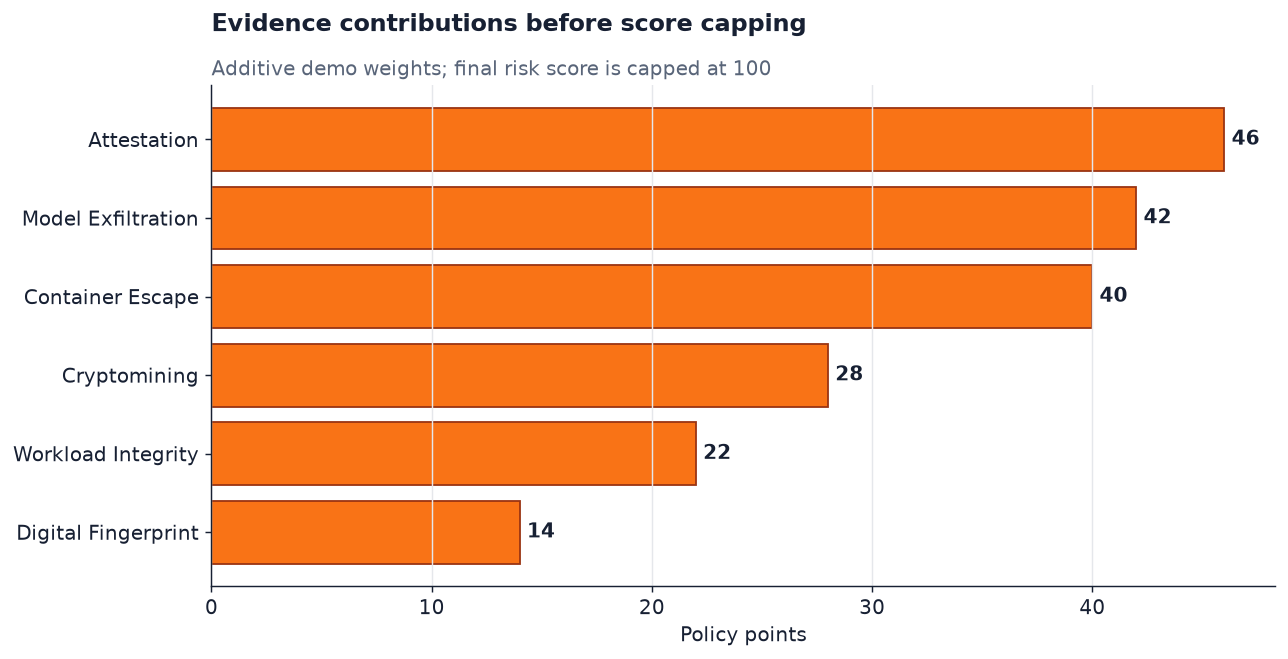

,severity,category,title,score
5,medium,digital-fingerprint,Workload behavior departed from its trusted fi...,14
4,high,workload-integrity,Unsigned image received privileged GPU access,22
1,high,cryptomining,GPU behavior resembles unauthorized cryptomining,28
3,critical,container-escape,Privileged GPU container reached the host PID ...,40
2,critical,model-exfiltration,Large external transfer followed model access,42
0,critical,attestation,GPU trust evidence failed policy,46


In [6]:
compromised_events = generate_events("compromised", 360, 84)
compromised_report = analyze_events(compromised_events, build_attestation(False), "compromised")
finding_frame = pd.DataFrame([item.to_dict() for item in compromised_report.findings]).sort_values("score")
fig, ax = plt.subplots(figsize=(10, 5.2))
bars = ax.barh(finding_frame["category"].str.replace("-", " ").str.title(), finding_frame["score"], color=ORANGE, edgecolor="#9a3412")
ax.bar_label(bars, padding=4, fontweight="bold")
ax.set_title("Evidence contributions before score capping", loc="left", fontweight="bold")
ax.text(0, 1.02, "Additive demo weights; final risk score is capped at 100", transform=ax.transAxes, color="#596579")
ax.set_xlabel("Policy points")
ax.grid(axis="x", color=GRID, linewidth=.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
finding_frame[["severity", "category", "title", "score"]]

## Takeaways

            1. **Attestation is a gate, not an ML feature.** Failed trust evidence independently changes normal behavior from **ALLOW** to **BLOCK**.
            2. **Trusted hardware is not trusted behavior.** Cryptomining, exfiltration, and host access still trigger containment on an attested GPU.
            3. **The production boundary is explicit.** Replace the fixture parser with NVIDIA Remote Attestation Service verification before using real model keys or confidential data.